# Fine-tuning and evaluation of DistilBERT

This notebook focuses on fine-tuning the pre-trained DistilBERT model for reviews sentiment classification, with a specific emphasis on comparing model performance before and after dataset balancing.

In [51]:
import numpy as np
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

In [52]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.utils import compute_class_weight
import re

In [53]:
import torch.nn as nn

In [54]:
from transformers import EarlyStoppingCallback

Loaded CSV files, and texts were cleaned by removing extra whitespace, URLs, and special characters.

In [55]:
train_df = pd.read_csv("data/train_imbalanced.csv")
balanced_train_df = pd.read_csv("data/train_balanced.csv")
val_df = pd.read_csv("data/validation_df.csv")
test_df = pd.read_csv("data/test_df.csv")

In [56]:
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

A dictionary was created to map text labels to numerical values.

In [57]:
label_mapping = {"bad": 0, "neutral": 1, "good": 2}

In [58]:
for df in [train_df, balanced_train_df, val_df, test_df]:
  df["Text"] = df["Text"].astype(str).apply(clean_text)
  df["labels"] = df["Score"].map(label_mapping)

In [59]:
train_dataset = Dataset.from_pandas(train_df)
train_balanced_dataset = Dataset.from_pandas(balanced_train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

Loaded the pre-trained distilbert-base-uncased tokenizer and model configured for 3 classification labels.

In [60]:
model_checkpoint = "distilbert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenization was applied to all datasets using the pre-trained tokenizer.

In [61]:
def tokenize_function(examples):
  return tokenizer(examples["Text"], padding="max_length", truncation=True, max_length=64)

In [62]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_balanced_train = train_balanced_dataset.map(tokenize_function,batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/39999 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

A compute_metrics function is created to calculate and return accuracy and macro F1-score.

In [63]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=1)

  acc = accuracy_score(labels, predictions)
  f1 = f1_score(labels, predictions, average="macro")

  return {"accuracy": acc, "f1": f1}

Training arguments were defined, the standard Trainer was initialized, and training was initiated.

In [64]:
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit = 1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.267207,0.187131,0.936400,0.798418
2,0.157145,0.178457,0.941200,0.821511
3,0.126146,0.185198,0.942000,0.821442


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.1670206298828125, metrics={'train_runtime': 705.3738, 'train_samples_per_second': 170.123, 'train_steps_per_second': 2.658, 'total_flos': 1987046415360000.0, 'train_loss': 0.1670206298828125, 'epoch': 3.0})

The training was repeated using a custom WeightedTrainer class that computes the loss with class weights balanced according to class representation to handle data imbalance.

In [67]:
train_labels = train_dataset["labels"]

In [73]:
weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(weights, dtype=torch.float)

In [75]:
class WeightedTrainer(Trainer):

  def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
    labels = inputs.get("labels")

    outputs = model(**inputs)
    logits = outputs.get("logits")

    weights = class_weights.to(logits.device)

    loss_fc = nn.CrossEntropyLoss(weight=weights)
    loss = loss_fc(
        logits.view(-1, self.model.config.num_labels), labels.view(-1)
    )

    return (loss, outputs) if return_outputs else loss

In [76]:
model2 = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

training_args2 = TrainingArguments(
    output_dir="./distilbert_results_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit = 1
)

trainer2 = WeightedTrainer(
    model=model2,
    args=training_args2,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

trainer2.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.565789,0.428547,0.906600,0.775904
2,0.364721,0.425470,0.904800,0.780816
3,0.282883,0.472938,0.923000,0.803327


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.368907861328125, metrics={'train_runtime': 630.778, 'train_samples_per_second': 190.241, 'train_steps_per_second': 2.973, 'total_flos': 1987046415360000.0, 'train_loss': 0.368907861328125, 'epoch': 3.0})

Model layers were selectively frozen, training arguments were configured with early stopping, and trainer3 was initiated for training.

In [80]:
model3 = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
for name, param in model3.named_parameters():
    if "transformer.layer.5" in name or "classifier" in name or "pre_classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [81]:
training_args3 = TrainingArguments(
    output_dir="./distilbert_results_v3",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit = 1
)

In [82]:
trainer3 = Trainer(
    model=model3,
    args=training_args3,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer3.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.351019,0.242144,0.914000,0.714282
2,0.234399,0.222011,0.921800,0.754450
3,0.224440,0.218065,0.923000,0.750472


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.259076953125, metrics={'train_runtime': 296.2709, 'train_samples_per_second': 675.058, 'train_steps_per_second': 10.548, 'total_flos': 1987046415360000.0, 'train_loss': 0.259076953125, 'epoch': 3.0})

Based on the evaluation on the validation dataset, the standard fine-tuned model (Model 1) achieved the best overall performance and was therefore selected as the final model.

In [83]:
model_path = "./distilbert_results/checkpoint-1250"

best_imb_model = AutoModelForSequenceClassification.from_pretrained(model_path)
best_imb_model.to("cuda")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [84]:
best_imb_model.save_pretrained("./best_imbalanced_distilbert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [85]:
trainer = Trainer(model=best_imb_model)

In [86]:
test_predictions = trainer.predict(tokenized_test)

logits = test_predictions.predictions
y_pred = np.argmax(logits, axis=1)
y_true = test_predictions.label_ids

In [87]:
print("Classification report on test dataset")
print(classification_report(y_true, y_pred, target_names=["bad", "neutral", "good"],digits=4))

Classification report on test dataset
              precision    recall  f1-score   support

         bad     0.8457    0.8264    0.8359       484
     neutral     0.6986    0.6945    0.6965       347
        good     0.9763    0.9794    0.9778      4169

    accuracy                         0.9448      5000
   macro avg     0.8402    0.8334    0.8368      5000
weighted avg     0.9444    0.9448    0.9446      5000



In [88]:
cm_final = confusion_matrix(y_true, y_pred)

In [89]:
class_names = ["bad", "neutral", "good"]

<Figure size 800x600 with 0 Axes>

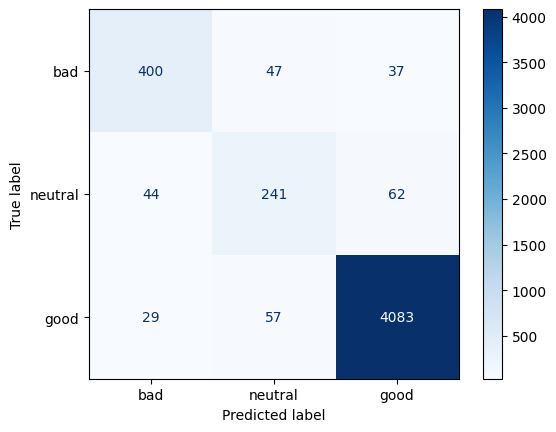

In [90]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.savefig("distilbert_unbalanced_train_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

The evaluation on the test dataset demonstrates strong overall performance with an accuracy of 94.48%. The model performs exceptionally well on the majority class (good) with an F1-score of 0.9778. While the performance on the minority class (bad) remains robust (F1-score of 0.8359), the neutral class presents a higher challenge (F1-score of 0.6965), often being confused with good or bad reviews.

# Balanced train dataset

The same training procedure is repeated for the balanced dataset.

In [91]:
model_checkpoint = "distilbert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [92]:
training_args = TrainingArguments(
    output_dir="./distilbert_balanced_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit = 1
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_balanced_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.506652,0.255099,0.910600,0.795802
2,0.338387,0.253902,0.914400,0.804170
3,0.280122,0.258423,0.917400,0.814011


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.34917188720703124, metrics={'train_runtime': 629.6447, 'train_samples_per_second': 190.579, 'train_steps_per_second': 2.978, 'total_flos': 1986996739199616.0, 'train_loss': 0.34917188720703124, 'epoch': 3.0})

In [93]:
model2 = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
for name, param in model2.named_parameters():
    if "transformer.layer.5" in name or "classifier" in name or "pre_classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [95]:
#for name, param in model2.named_parameters():
#    print(f"{name}: {param.requires_grad}")

In [96]:
training_args2 = TrainingArguments(
    output_dir="./distilbert_balanced_results_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit = 1
)

In [97]:
trainer = Trainer(
    model=model2,
    args=training_args2,
    train_dataset=tokenized_balanced_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.644798,0.388353,0.858000,0.711583
2,0.501302,0.393874,0.854400,0.715116
3,0.477894,0.352773,0.874000,0.737001
4,0.442279,0.336407,0.880000,0.748113
5,0.434273,0.343477,0.878200,0.747388


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3125, training_loss=0.4918536865234375, metrics={'train_runtime': 506.3662, 'train_samples_per_second': 394.961, 'train_steps_per_second': 6.171, 'total_flos': 3311661231999360.0, 'train_loss': 0.4918536865234375, 'epoch': 5.0})

Based on the evaluation on the validation dataset, the standard fine-tuned model (Model 1) achieved the best overall performance and was therefore selected as the final model.

In [98]:
best_model_balanced = AutoModelForSequenceClassification.from_pretrained("./distilbert_balanced_results/checkpoint-1875")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [99]:
best_model_balanced.to("cuda")

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [100]:
best_model_balanced.save_pretrained("./best_balanced_distilbert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [101]:
trainer = Trainer(model=best_model_balanced)

In [102]:
predictions = trainer.predict(tokenized_test)

In [103]:
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [104]:
print("Classification report on test dataset")
print(classification_report(y_true, y_pred, target_names=["bad", "neutral", "good"],digits = 4))

Classification report on test dataset
              precision    recall  f1-score   support

         bad     0.8239    0.8988    0.8597       484
     neutral     0.5209    0.8617    0.6493       347
        good     0.9941    0.9295    0.9607      4169

    accuracy                         0.9218      5000
   macro avg     0.7796    0.8966    0.8232      5000
weighted avg     0.9448    0.9218    0.9293      5000



In [105]:
cm_final_balanced = confusion_matrix(y_true, y_pred)

<Figure size 800x600 with 0 Axes>

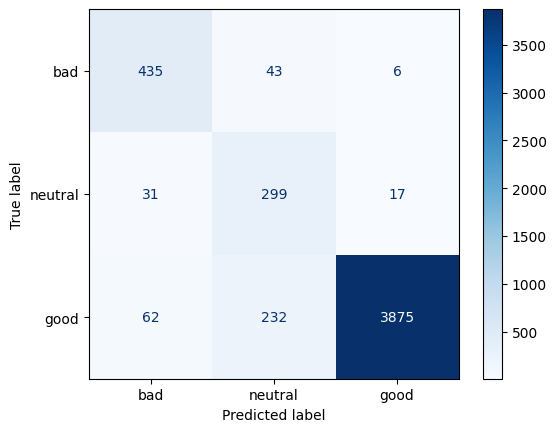

In [106]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final_balanced, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.savefig("distilbert_balanced_train_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Resampling the training data successfully accomplished its primary purpose by markedly improving the recall for minority classes (bad and neutral), meaning the model no longer neglects rare classes. However, the trade-off is an increased number of false good predictions for the neutral class, which is a common occurrence when balancing datasets.